# O25 Practical Code
Second attempt

# Practical 1 - Computing the Kaplan-Yorke Dimension

## Problem definition + Simulation
The Quasi-Static Spring Slider

In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

from tqdm import tqdm

## CONSTANTS

beta_1 = 1
beta_2 = 0.84
rho = 0.048

kappa_prime = 0.8544
kappa_cr_1 = beta_1 - 1
kappa_cr_2 = (
    kappa_cr_1 + rho*(2*beta_1 + (beta_2-1)*(2+rho)) + np.sqrt(
        4*rho**2 * (kappa_cr_1+beta_2) + (kappa_cr_1 + rho**2 * (beta_2-1))**2
    )
) / (2*(1+rho))

kappa = kappa_cr_2 * kappa_prime
## define EOMS
print(kappa)
v_0 = 1

def func(input_vars):
    x, y, z = input_vars

    ex = np.exp(x)

    fx = -kappa * (ex - v_0)
    + ex * (x*(beta_1-1) + y - z)
    + rho * ex * (beta_2*x + z)
    
    fy = -kappa * (ex-v_0)

    fz = -rho*ex*(beta_2*x+z)

    return np.array([fx, fy, fz], dtype=np.float32)

def t_func(t, input_vars):
    
    return func(input_vars)

## alternate jacobian from lectures potentially instead?
#from scipy.differentiate import jacobian

## manual implementation
def jacobian(input_vars, kappa=kappa, beta_1=beta_1, beta_2=beta_2, rho=rho):

    assert len(input_vars) == 3

    x, y, z = input_vars

    ex = np.exp(x)

    J11 = -kappa * ex + ex * (
        x*(beta_1 - 1) + y - z + beta_1 - 1
    ) + rho * ex * (beta_2 * x + z + beta_2)
    J12 = ex
    J13 = ex * (-1 + rho)

    J21 = -kappa * ex
    J22 = 0
    J23 = 0

    J31 = -rho * ex * beta_2 * (x + 1)
    J32 = 0
    J33 = -rho * ex


    jac = np.array([
        [J11, J12, J13],
        [J21, J22, J23],
        [J31, J32, J33]
    ])

    return jac

0.06858744329064924


### Part 1: Numerical Simulation

In [17]:
t_start = 0
t_transient=1000
t_end = 10000
dt = 0.1

t_eval = np.arange(t_transient, t_end, dt)
X_0 = [0.5, 0, 0]

soln = solve_ivp(t_func, (t_start, t_end), X_0, method='RK45', t_eval=t_eval)

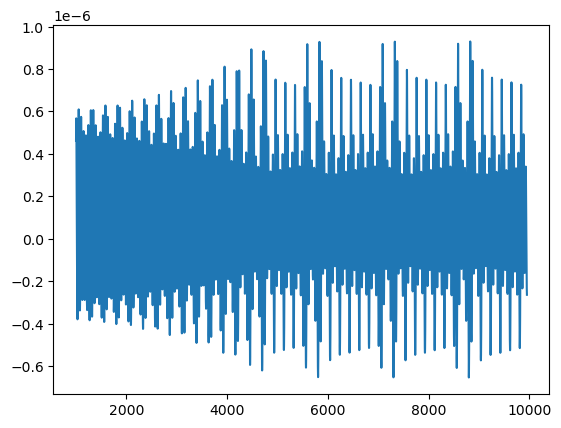

In [18]:
n_points = 500

t = soln.t[:-n_points]
x, y, z = soln.y[:,:-n_points]

fig, ax = plt.subplots()#subplot_kw={'projection':'3d'})

ax.plot(t, x)

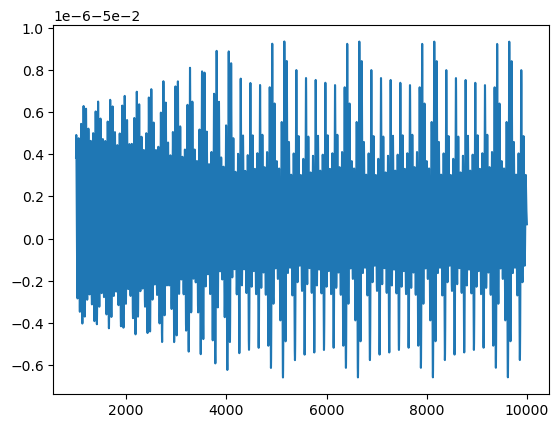

In [14]:
plt.plot(t, y)